


Generates synthetic ML, and threats datasets loaded from open ASC ; trains KNN/Naïve Bayes/Random Forest; shows per-seed tables for seeds 1–10 and averages; and plots confusion counts. 


In [1]:

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tara_pipeline import (
    generate_aco_dataset,
    generate_ml_dataset,
    load_threats_as_ml,
    evaluate_models,
    evaluate_models_multi,
)


## Generate/save datasets

In [2]:

aco_df = generate_aco_dataset(total_rows=6000, asset_count=6, seed=11)
ml_df = generate_ml_dataset(per_attack=900)
threats_ml_df = load_threats_as_ml()
aco_df.to_csv('data/aco_tara_dataset.csv', index=False)
ml_df.to_csv('data/ml_tara_dataset.csv', index=False)
threats_ml_df.to_csv('data/threats_ml_dataset.csv', index=False)
aco_df.head(5), ml_df.head(5), threats_ml_df.head(5)


(  scenario_id identified_asset     attack_cluster impact_rating  \
 0       DS001          Asset 1           Spoofing         Major   
 1       DS002          Asset 1        Repudiation         Minor   
 2       DS003          Asset 6  Denial-of-service        Severe   
 3       DS004          Asset 4        Repudiation         Minor   
 4       DS005          Asset 5          Tampering         Major   
 
   attack_feasibility_rating  risk_value  
 0                      High           4  
 1                       Low           1  
 2                      High           5  
 3                       Low           1  
 4                      High           5  ,
    scenario_id          asset attack_type targeted_property impact_rating
 0            1  tire_pressure    spoofing      availability         major
 1            2            ecu    spoofing      availability         major
 2            3     ota_module    spoofing      availability         major
 3            4  tire_pressure 

## Impact rating distribution (synthetic ML dataset)

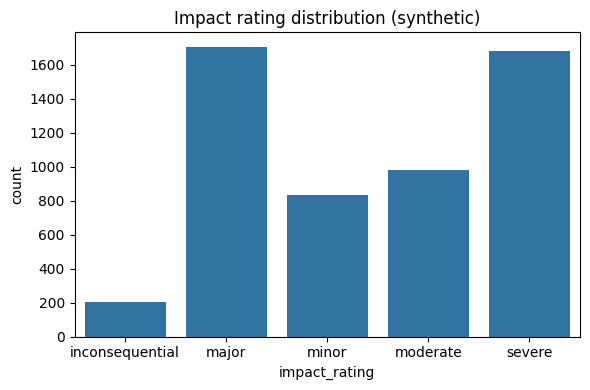

In [3]:

plt.figure(figsize=(6,4))
sns.countplot(data=ml_df, x='impact_rating', order=sorted(ml_df['impact_rating'].unique()))
plt.title('Impact rating distribution (synthetic)')
plt.tight_layout()
plt.show()


## Evaluate on synthetic ML dataset 

In [4]:

results = evaluate_models(ml_df)
metrics = pd.DataFrame([
    {
        'model': name.upper(),
        'accuracy': res['accuracy'] * 100,
        'precision': res['precision'] * 100,
        'recall': res['recall'] * 100,
        'f1': res['f1'] * 100,
        'true_positive': res['tp'],
        'true_negative': res['tn'],
        'false_positive': res['fp'],
        'false_negative': res['fn'],
    }
    for name, res in results.items()
]).set_index('model')
metrics


,accuracy,precision,recall,f1,true_positive,true_negative,false_positive,false_negative
model,,,,,,,,
KNN,88.703704,85.342533,88.703704,86.911441,958,4198,122,122
NAIVE_BAYES,88.703704,85.342533,88.703704,86.911441,958,4198,122,122
RANDOM_FOREST,87.962963,86.060156,87.962963,86.827608,950,4190,130,130


### Evaluate on synthetic ML dataset (seeds 1–10)

In [5]:

seed_metrics = evaluate_models_multi(ml_df, seeds=list(range(1,11)))
seed_metrics[['seed','model','accuracy','precision','recall','f1']]


,seed,model,accuracy,precision,recall,f1
0,1,KNN,0.888889,0.865558,0.888889,0.874268
1,1,NAIVE_BAYES,0.891667,0.857471,0.891667,0.874155
2,1,RANDOM_FOREST,0.879630,0.862239,0.879630,0.870229
3,2,KNN,0.900000,0.866366,0.900000,0.882153
4,2,NAIVE_BAYES,0.900926,0.867355,0.900926,0.883060
5,2,RANDOM_FOREST,0.888889,0.867861,0.888889,0.877234
6,3,KNN,0.885185,0.851316,0.885185,0.867691
7,3,NAIVE_BAYES,0.885185,0.851316,0.885185,0.867691
8,3,RANDOM_FOREST,0.871296,0.851391,0.871296,0.861105
9,4,KNN,0.889815,0.856323,0.889815,0.871885


### Average over seeds (synthetic ML dataset)

In [6]:

avg_metrics = seed_metrics.groupby('model')[['accuracy','precision','recall','f1']].mean().reset_index()
avg_metrics


,model,accuracy,precision,recall,f1
0,KNN,0.891667,0.861236,0.891667,0.874519
1,NAIVE_BAYES,0.892037,0.858432,0.892037,0.874137
2,RANDOM_FOREST,0.880000,0.860067,0.880000,0.868850


### Metric comparison (accuracy, precision, recall, F1)

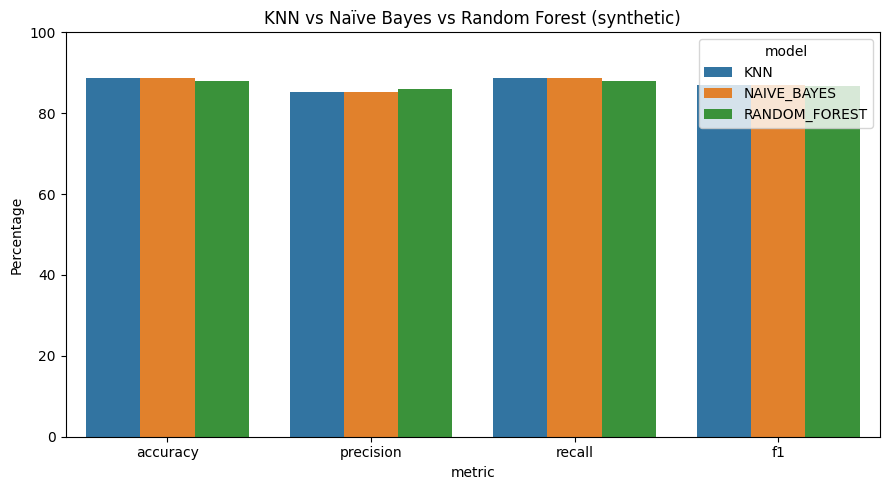

In [7]:

metrics_reset = metrics.reset_index().melt(id_vars='model', var_name='metric', value_name='value')
plt.figure(figsize=(9, 5))
sns.barplot(data=metrics_reset[metrics_reset['metric'].isin(['accuracy','precision','recall','f1'])], x='metric', y='value', hue='model')
plt.title('KNN vs Naïve Bayes vs Random Forest (synthetic)')
plt.ylabel('Percentage')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()


### Confusion counts as histogram (synthetic)

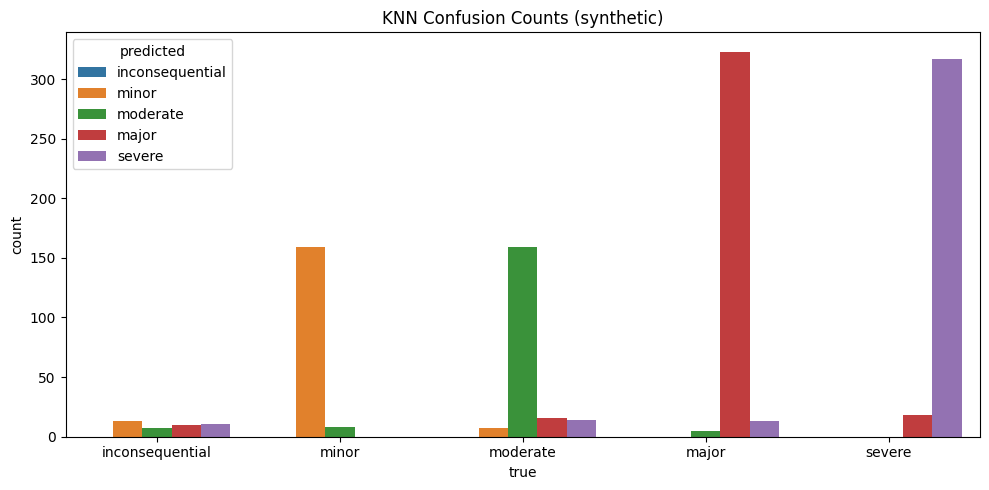

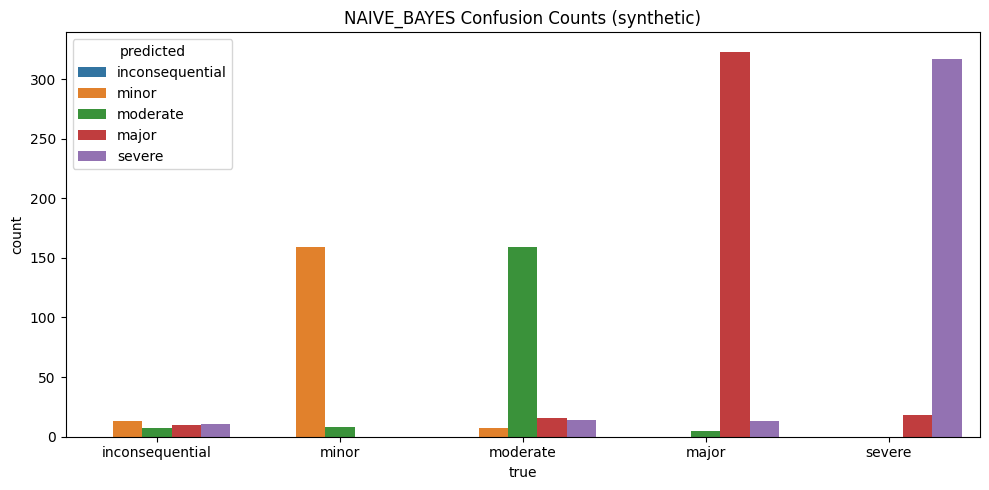

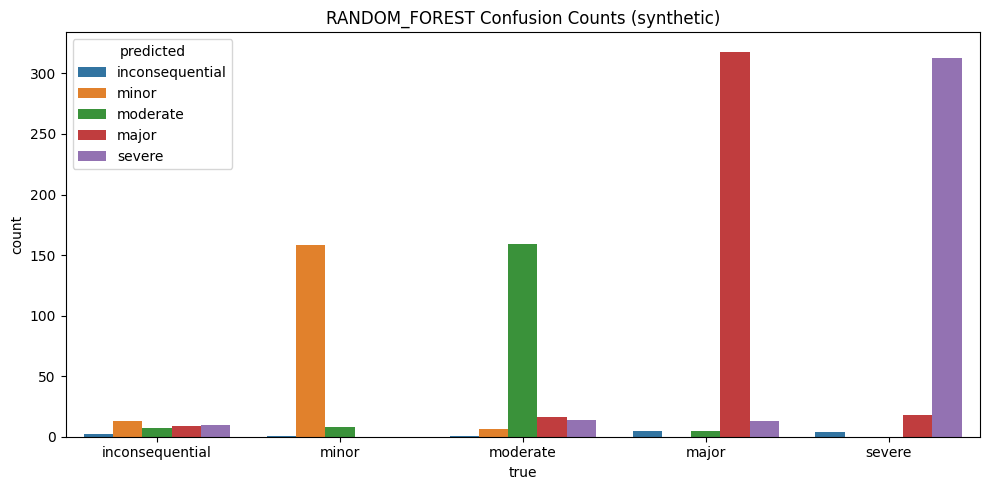

In [8]:

for name, res in results.items():
    cm_df = res['confusion_matrix']
    cm_melt = cm_df.reset_index().melt(id_vars='index', var_name='predicted', value_name='count')
    cm_melt = cm_melt.rename(columns={'index': 'true'})
    plt.figure(figsize=(10, 5))
    sns.barplot(data=cm_melt, x='true', y='count', hue='predicted')
    plt.title(f"{name.upper()} Confusion Counts (synthetic)")
    plt.tight_layout()
    plt.show()


## Evaluate on threats.json-derived dataset (single split)

In [9]:

results_threats = evaluate_models(threats_ml_df)
metrics_threats = pd.DataFrame([
    {
        'model': name.upper(),
        'accuracy': res['accuracy'] * 100,
        'precision': res['precision'] * 100,
        'recall': res['recall'] * 100,
        'f1': res['f1'] * 100,
        'true_positive': res['tp'],
        'true_negative': res['tn'],
        'false_positive': res['fp'],
        'false_negative': res['fn'],
    }
    for name, res in results_threats.items()
]).set_index('model')
metrics_threats


,accuracy,precision,recall,f1,true_positive,true_negative,false_positive,false_negative
model,,,,,,,,
KNN,61.764706,61.533613,61.764706,61.595673,21,123,13,13
NAIVE_BAYES,58.823529,58.349494,58.823529,58.382353,20,122,14,14
RANDOM_FOREST,64.705882,64.404223,64.705882,64.327731,22,124,12,12


### Evaluate on threats.json-derived dataset (seeds 1–10)

In [10]:

seed_metrics_threats = evaluate_models_multi(threats_ml_df, seeds=list(range(1,11)))
seed_metrics_threats[['seed','model','accuracy','precision','recall','f1']]


,seed,model,accuracy,precision,recall,f1
0,1,KNN,0.529412,0.522948,0.529412,0.524370
1,1,NAIVE_BAYES,0.647059,0.651765,0.647059,0.627005
2,1,RANDOM_FOREST,0.647059,0.651765,0.647059,0.627005
3,2,KNN,0.823529,0.846646,0.823529,0.823529
4,2,NAIVE_BAYES,0.705882,0.705882,0.705882,0.705882
5,2,RANDOM_FOREST,0.794118,0.799465,0.794118,0.790212
6,3,KNN,0.705882,0.709602,0.705882,0.697264
7,3,NAIVE_BAYES,0.794118,0.796569,0.794118,0.794656
8,3,RANDOM_FOREST,0.823529,0.823529,0.823529,0.823529
9,4,KNN,0.705882,0.723137,0.705882,0.689171


### Average over seeds (threats.json dataset)

In [11]:

avg_metrics_threats = seed_metrics_threats.groupby('model')[['accuracy','precision','recall','f1']].mean().reset_index()
avg_metrics_threats


,model,accuracy,precision,recall,f1
0,KNN,0.697059,0.720613,0.697059,0.689855
1,NAIVE_BAYES,0.670588,0.670222,0.670588,0.658628
2,RANDOM_FOREST,0.720588,0.730453,0.720588,0.711981


### Metric comparison (threats.json dataset)

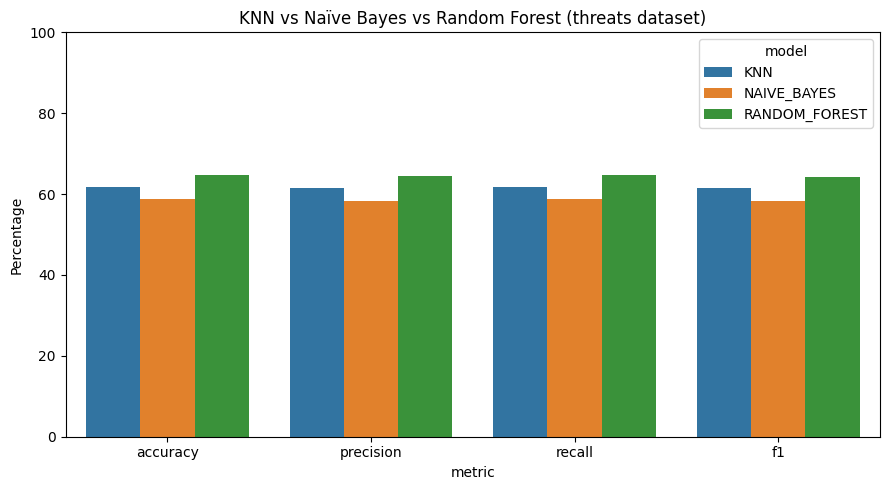

In [12]:

metrics_reset_t = metrics_threats.reset_index().melt(id_vars='model', var_name='metric', value_name='value')
plt.figure(figsize=(9, 5))
sns.barplot(data=metrics_reset_t[metrics_reset_t['metric'].isin(['accuracy','precision','recall','f1'])], x='metric', y='value', hue='model')
plt.title('KNN vs Naïve Bayes vs Random Forest (threats dataset)')
plt.ylabel('Percentage')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()


### Confusion counts as histogram (threats.json dataset)

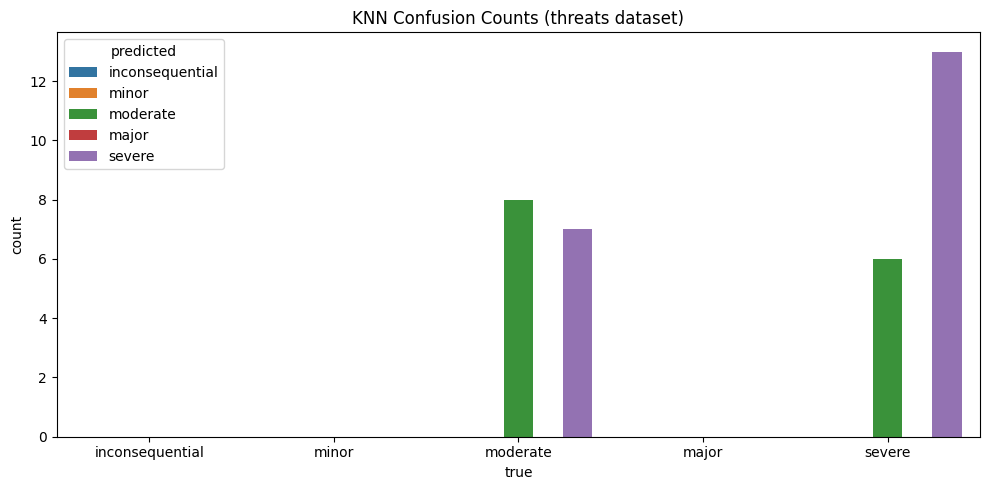

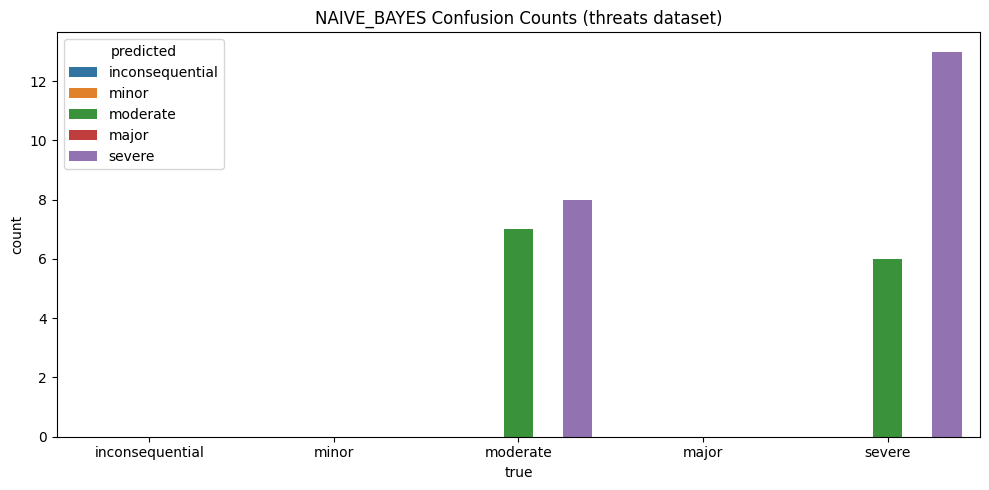

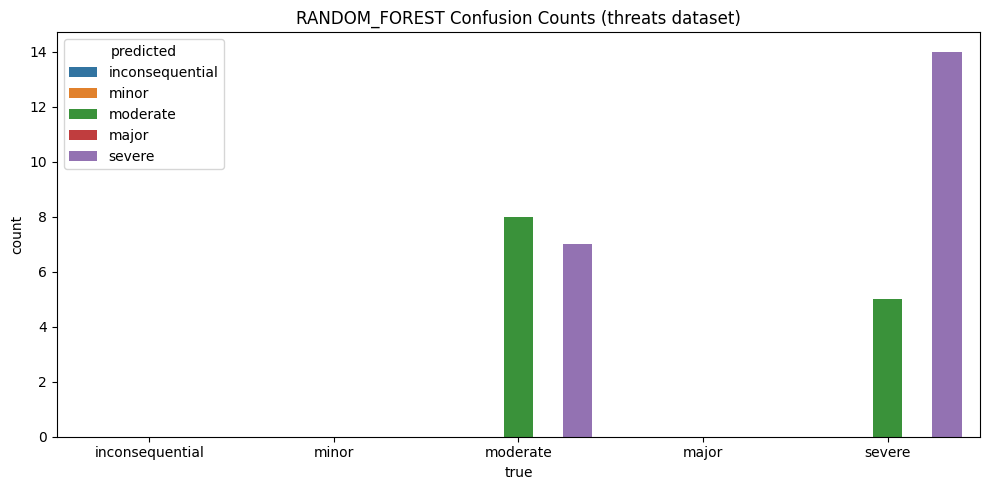

In [13]:

for name, res in results_threats.items():
    cm_df = res['confusion_matrix']
    cm_melt = cm_df.reset_index().melt(id_vars='index', var_name='predicted', value_name='count')
    cm_melt = cm_melt.rename(columns={'index': 'true'})
    plt.figure(figsize=(10, 5))
    sns.barplot(data=cm_melt, x='true', y='count', hue='predicted')
    plt.title(f"{name.upper()} Confusion Counts (threats dataset)")
    plt.tight_layout()
    plt.show()
